In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

c:\Users\tirup\equipment-failure-ai\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pip install ipywidgets

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 914.9/914.9 kB 10.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   -------------------------------------- - 2.1/2.2 MB 9.8 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 8.8 MB/s  0:00:00

   ------------- -------------------------- 1/3 [jupyterlab_widgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

df_model = df.drop(columns=["UDI", "Product ID"])
df_model = pd.get_dummies(df_model, columns=["Type"])

df_model.columns = [
    col.replace("[", "")
       .replace("]", "")
       .replace("<", "")
       .replace(" ", "_")
       .replace("/", "_")
    for col in df_model.columns
]

df_model["temperature_difference"] = (
    df_model["Process_temperature_K"] - df_model["Air_temperature_K"]
)

df_model["mechanical_stress"] = (
    df_model["Torque_Nm"] * df_model["Rotational_speed_rpm"]
)

df_model["wear_stress"] = (
    df_model["Tool_wear_min"] * df_model["Torque_Nm"]
)

df_model["thermal_wear_stress"] = (
    df_model["Process_temperature_K"] * df_model["Tool_wear_min"]
)

df_model["power_load"] = (
    df_model["Torque_Nm"] * df_model["Rotational_speed_rpm"] / 1000
)

In [3]:
X = df_model.drop(columns=["Machine_failure"])
y = df_model["Machine_failure"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
explainer = shap.Explainer(model, X_train)

NameError: name 'model' is not defined

In [8]:
import shap
import joblib
import pandas as pd
import numpy as np

In [10]:
model = joblib.load("../models/failure_model_v2.pkl")

In [11]:
model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [12]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

df_model = df.drop(columns=["UDI", "Product ID"])
df_model = pd.get_dummies(df_model, columns=["Type"])

df_model.columns = [
    col.replace("[","")
       .replace("]","")
       .replace("<","")
       .replace(" ","_")
       .replace("/","_")
    for col in df_model.columns
]

In [13]:
df_model["temperature_difference"] = (
    df_model["Process_temperature_K"] -
    df_model["Air_temperature_K"]
)

df_model["mechanical_stress"] = (
    df_model["Torque_Nm"] *
    df_model["Rotational_speed_rpm"]
)

df_model["wear_stress"] = (
    df_model["Tool_wear_min"] *
    df_model["Torque_Nm"]
)

df_model["thermal_wear_stress"] = (
    df_model["Process_temperature_K"] *
    df_model["Tool_wear_min"]
)

df_model["power_load"] = (
    df_model["Torque_Nm"] *
    df_model["Rotational_speed_rpm"] / 1000
)

In [14]:
X = df_model.drop(columns=["Machine_failure"])
y = df_model["Machine_failure"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
explainer = shap.Explainer(model, X_train)

TypeError: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'

In [17]:
print(X_train.dtypes)

Air_temperature_K         float64
Process_temperature_K     float64
Rotational_speed_rpm        int64
Torque_Nm                 float64
Tool_wear_min               int64
TWF                         int64
HDF                         int64
PWF                         int64
OSF                         int64
RNF                         int64
Type_H                       bool
Type_L                       bool
Type_M                       bool
temperature_difference    float64
mechanical_stress         float64
wear_stress               float64
thermal_wear_stress       float64
power_load                float64
dtype: object


In [18]:
print(X_train.dtypes.value_counts())

float64    8
int64      7
bool       3
Name: count, dtype: int64


In [19]:
bad_cols = X_train.columns[X_train.dtypes == "object"]
print("Object columns:", list(bad_cols))

Object columns: []


In [20]:
X = df_model.drop(columns=["Machine_failure"])
y = df_model["Machine_failure"]

# Convert booleans to ints if present
X = X.replace({True: 1, False: 0})

# Force all columns to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Optional sanity check
print(X.dtypes.value_counts())
print("Any nulls after conversion:", X.isnull().sum().sum())

int64      10
float64     8
Name: count, dtype: int64
Any nulls after conversion: 0


In [21]:
X = X.astype("float64")
y = y.astype("int64")

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.dtypes.value_counts())
print(X_train.shape, X_test.shape)

float64    18
Name: count, dtype: int64
(8000, 18) (2000, 18)


In [23]:
explainer = shap.TreeExplainer(model)

In [24]:
explainer = shap.TreeExplainer(model)

In [25]:
shap_values = explainer.shap_values(X_test)

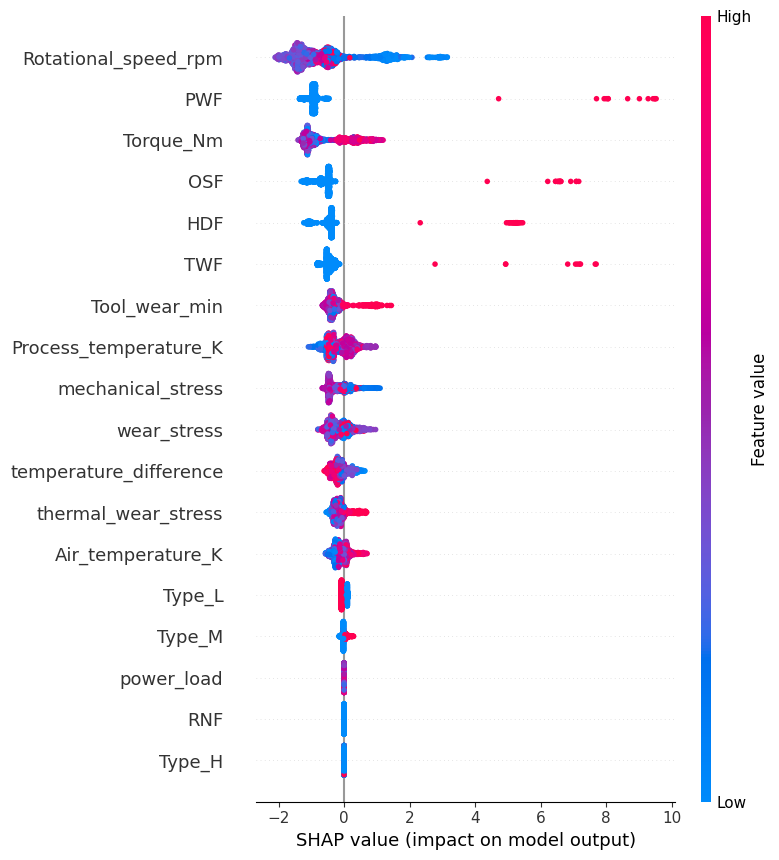

In [26]:
shap.summary_plot(shap_values, X_test)

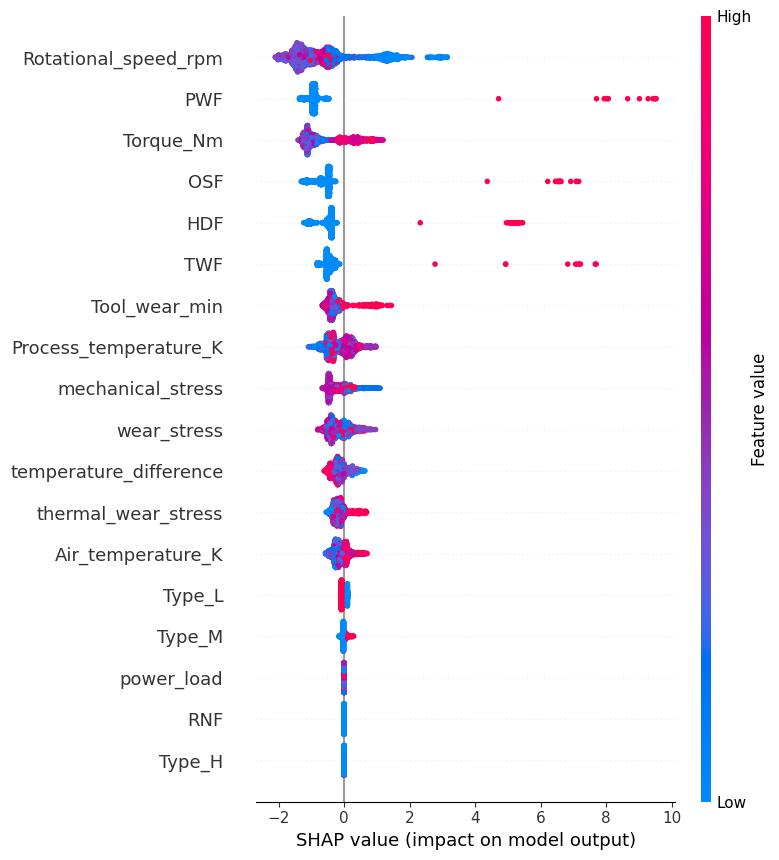

In [27]:
shap.summary_plot(shap_values, X_test)

float64    18
Name: count, dtype: int64
Any nulls: 0


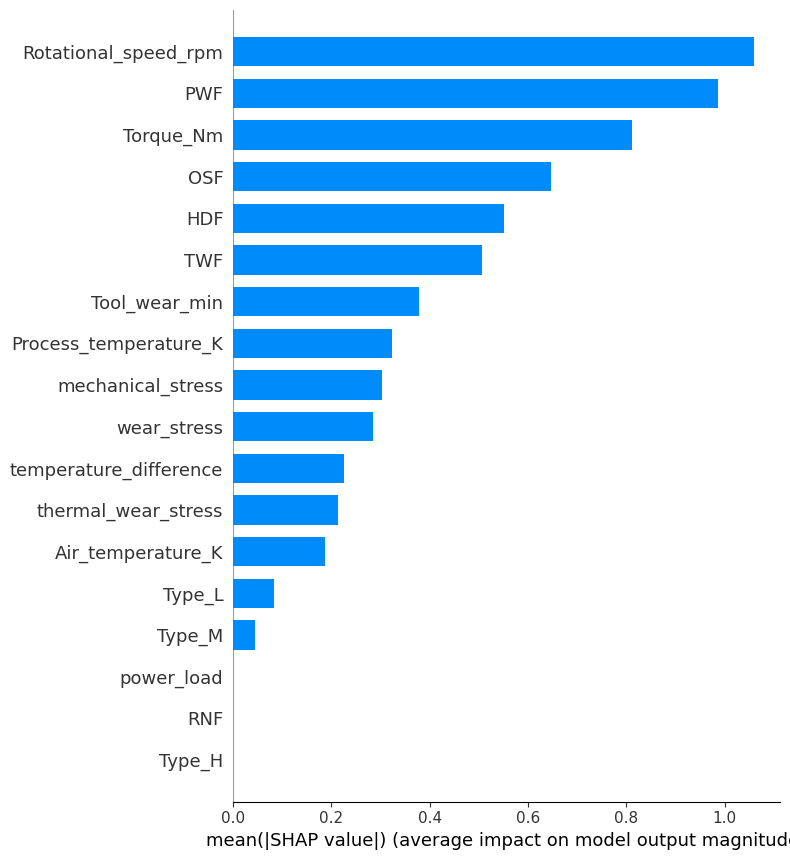

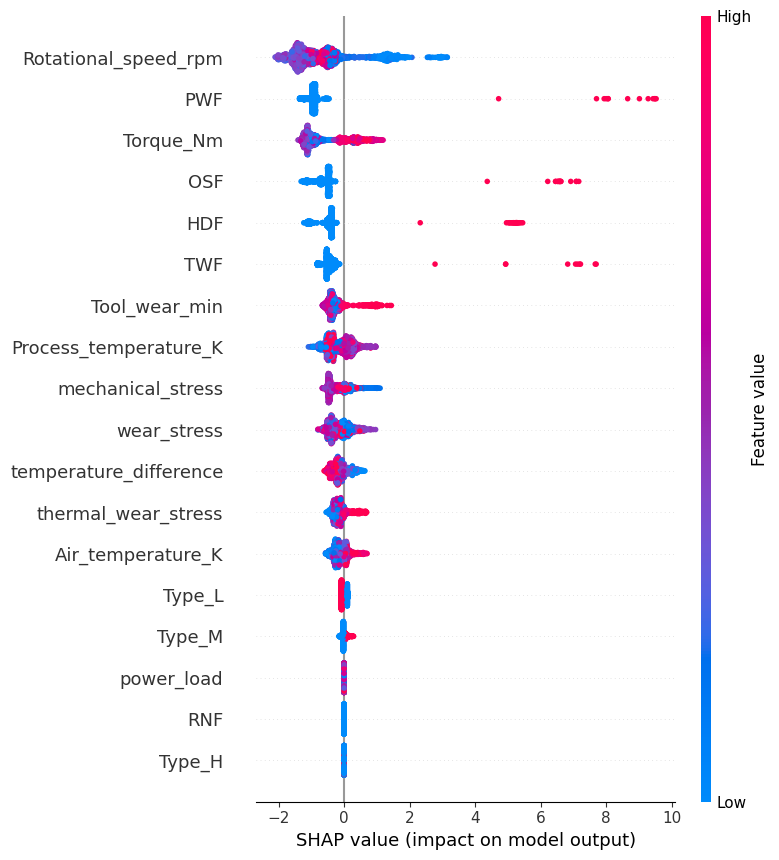

In [28]:
import pandas as pd
import numpy as np
import shap
import joblib
from sklearn.model_selection import train_test_split

# Load model
model = joblib.load("../models/failure_model_v2.pkl")

# Rebuild dataset
df = pd.read_csv("../data/raw/ai4i2020.csv")

df_model = df.drop(columns=["UDI", "Product ID"])
df_model = pd.get_dummies(df_model, columns=["Type"])

df_model.columns = [
    col.replace("[", "")
       .replace("]", "")
       .replace("<", "")
       .replace(" ", "_")
       .replace("/", "_")
    for col in df_model.columns
]

# Engineered features
df_model["temperature_difference"] = (
    df_model["Process_temperature_K"] - df_model["Air_temperature_K"]
)

df_model["mechanical_stress"] = (
    df_model["Torque_Nm"] * df_model["Rotational_speed_rpm"]
)

df_model["wear_stress"] = (
    df_model["Tool_wear_min"] * df_model["Torque_Nm"]
)

df_model["thermal_wear_stress"] = (
    df_model["Process_temperature_K"] * df_model["Tool_wear_min"]
)

df_model["power_load"] = (
    df_model["Torque_Nm"] * df_model["Rotational_speed_rpm"] / 1000
)

# Features and target
X = df_model.drop(columns=["Machine_failure"])
y = df_model["Machine_failure"]

# Clean dtypes
X = X.replace({True: 1, False: 0})
X = X.apply(pd.to_numeric, errors="coerce").astype("float64")
y = y.astype("int64")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.dtypes.value_counts())
print("Any nulls:", X_train.isnull().sum().sum())

# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plots
shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.summary_plot(shap_values, X_test)

In [29]:
print(X_train.dtypes.value_counts())
print("Any nulls:", X_train.isnull().sum().sum())

float64    18
Name: count, dtype: int64
Any nulls: 0


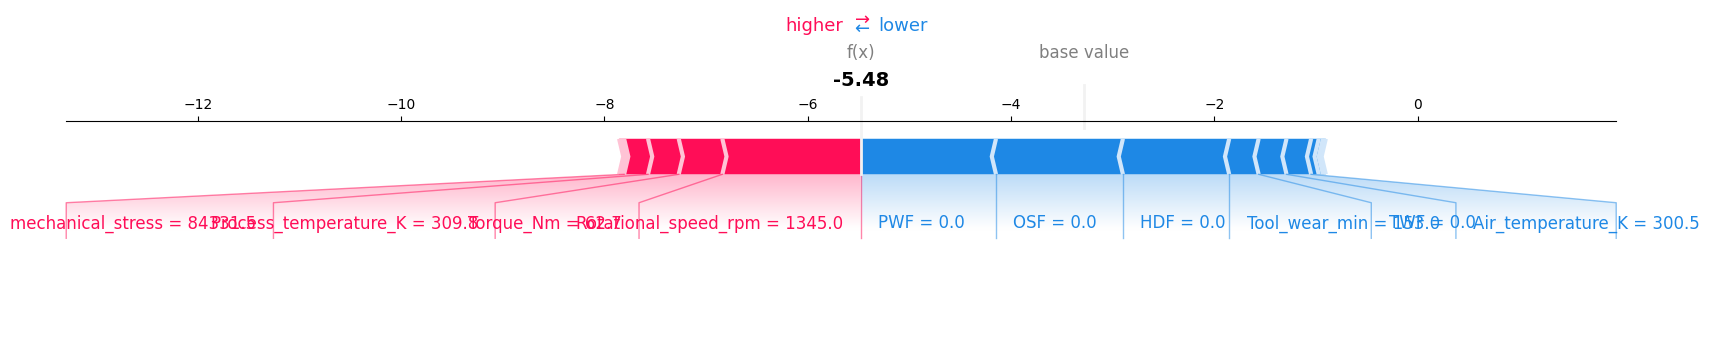

In [31]:
sample_index = 0

sample = X_test.iloc[[sample_index]]
sample_shap_values = explainer.shap_values(sample)

shap.force_plot(
    explainer.expected_value,
    sample_shap_values[0],
    sample,
    matplotlib=True
)

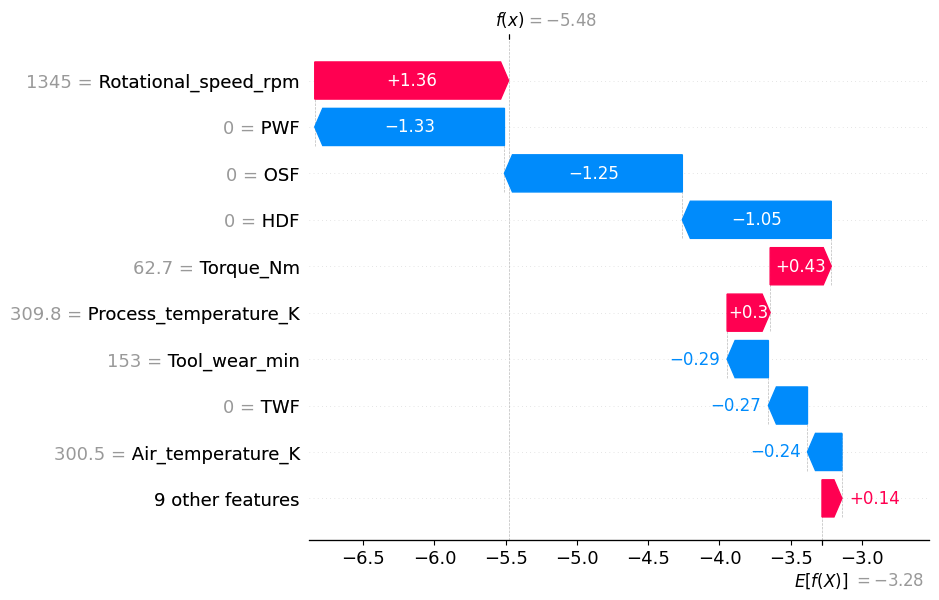

In [32]:
shap.waterfall_plot(
    shap.Explanation(
        values=sample_shap_values[0],
        base_values=explainer.expected_value,
        data=sample.iloc[0],
        feature_names=X_test.columns
    )
)

In [33]:
sample_index = 0
sample = X_test.iloc[[sample_index]]
sample_shap_values = explainer.shap_values(sample)

feature_impact = pd.DataFrame({
    "feature": X_test.columns,
    "shap_value": sample_shap_values[0],
    "abs_shap": np.abs(sample_shap_values[0])
}).sort_values("abs_shap", ascending=False)

feature_impact.head(5)

,feature,shap_value,abs_shap
2,Rotational_speed_rpm,1.360671,1.360671
7,PWF,-1.331257,1.331257
8,OSF,-1.248612,1.248612
6,HDF,-1.045217,1.045217
3,Torque_Nm,0.428976,0.428976


In [34]:
feature_name_map = {
    "Air_temperature_K": "air temperature",
    "Process_temperature_K": "process temperature",
    "Rotational_speed_rpm": "rotational speed",
    "Torque_Nm": "torque",
    "Tool_wear_min": "tool wear",
    "Type_H": "high-quality machine type",
    "Type_L": "low-quality machine type",
    "Type_M": "medium-quality machine type",
    "temperature_difference": "temperature difference",
    "mechanical_stress": "mechanical stress",
    "wear_stress": "wear-related stress",
    "thermal_wear_stress": "thermal wear stress",
    "power_load": "power load"
}

top_features_raw = feature_impact.head(3)["feature"].tolist()
top_features_readable = [feature_name_map.get(f, f) for f in top_features_raw]

explanation_text = (
    f"Failure risk increased mainly due to high {top_features_readable[0]}, "
    f"{top_features_readable[1]}, and {top_features_readable[2]}."
)

print(explanation_text)

Failure risk increased mainly due to high rotational speed, PWF, and OSF.


In [35]:
global_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": np.abs(shap_values).mean(axis=0)
}).sort_values("importance", ascending=False)

global_importance.to_csv("../data/processed/shap_global_importance.csv", index=False)
global_importance.head(10)

,feature,importance
2,Rotational_speed_rpm,1.059803
7,PWF,0.986544
3,Torque_Nm,0.811178
8,OSF,0.646116
6,HDF,0.550774
5,TWF,0.505551
4,Tool_wear_min,0.377442
1,Process_temperature_K,0.324282
14,mechanical_stress,0.302297
15,wear_stress,0.285559


In [36]:
df_model = df.drop(columns=[
    "UDI",
    "Product ID",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
])

df_model = pd.get_dummies(df_model, columns=["Type"])

df_model.columns = [
    col.replace("[", "")
       .replace("]", "")
       .replace("<", "")
       .replace(" ", "_")
       .replace("/", "_")
    for col in df_model.columns
]

In [37]:
df_model["temperature_difference"] = (
    df_model["Process_temperature_K"] - df_model["Air_temperature_K"]
)

df_model["mechanical_stress"] = (
    df_model["Torque_Nm"] * df_model["Rotational_speed_rpm"]
)

df_model["wear_stress"] = (
    df_model["Tool_wear_min"] * df_model["Torque_Nm"]
)

df_model["thermal_wear_stress"] = (
    df_model["Process_temperature_K"] * df_model["Tool_wear_min"]
)

df_model["power_load"] = (
    df_model["Torque_Nm"] * df_model["Rotational_speed_rpm"] / 1000
)

In [38]:
df_model["temperature_difference"] = (
    df_model["Process_temperature_K"] - df_model["Air_temperature_K"]
)

df_model["mechanical_stress"] = (
    df_model["Torque_Nm"] * df_model["Rotational_speed_rpm"]
)

df_model["wear_stress"] = (
    df_model["Tool_wear_min"] * df_model["Torque_Nm"]
)

df_model["thermal_wear_stress"] = (
    df_model["Process_temperature_K"] * df_model["Tool_wear_min"]
)

df_model["power_load"] = (
    df_model["Torque_Nm"] * df_model["Rotational_speed_rpm"] / 1000
)

In [39]:
X = df_model.drop(columns=["Machine_failure"])
y = df_model["Machine_failure"]

X = X.replace({True: 1, False: 0})
X = X.apply(pd.to_numeric, errors="coerce").astype("float64")
y = y.astype("int64")

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train.values, y_train.values)

y_pred_xgb = xgb_model.predict(X_test.values)
y_prob_xgb = xgb_model.predict_proba(X_test.values)[:, 1]

In [42]:
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.93      0.79      0.86        68

    accuracy                           0.99      2000
   macro avg       0.96      0.90      0.93      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9876765923760809
Precision: 0.9310344827586207
Recall: 0.7941176470588235
F1 Score: 0.8571428571428571


In [43]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train.values, y_train.values)

y_pred_xgb = xgb_model.predict(X_test.values)
y_prob_xgb = xgb_model.predict_proba(X_test.values)[:,1]

In [44]:
import joblib, os

os.makedirs("../models", exist_ok=True)
joblib.dump(xgb_model, "../models/failure_model_clean.pkl")

['../models/failure_model_clean.pkl']

In [45]:
import shap
import joblib

model = joblib.load("../models/failure_model_clean.pkl")

In [46]:
explainer = shap.TreeExplainer(model)

In [47]:
shap_values = explainer.shap_values(X_test)

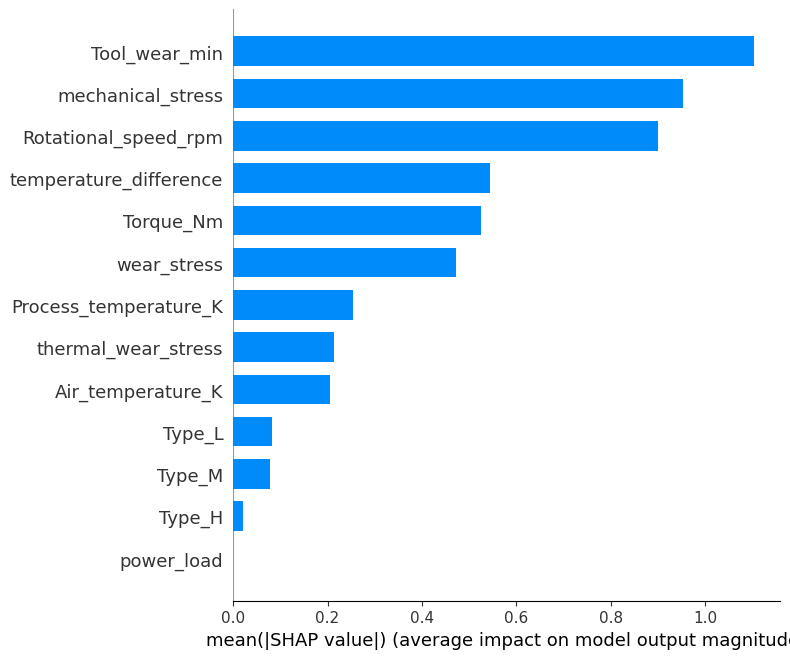

In [48]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

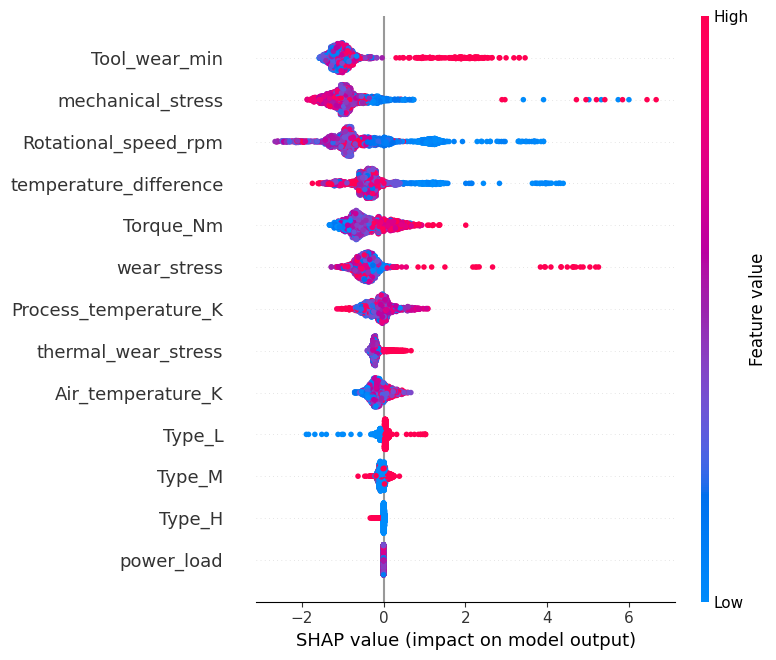

In [49]:
shap.summary_plot(shap_values, X_test)

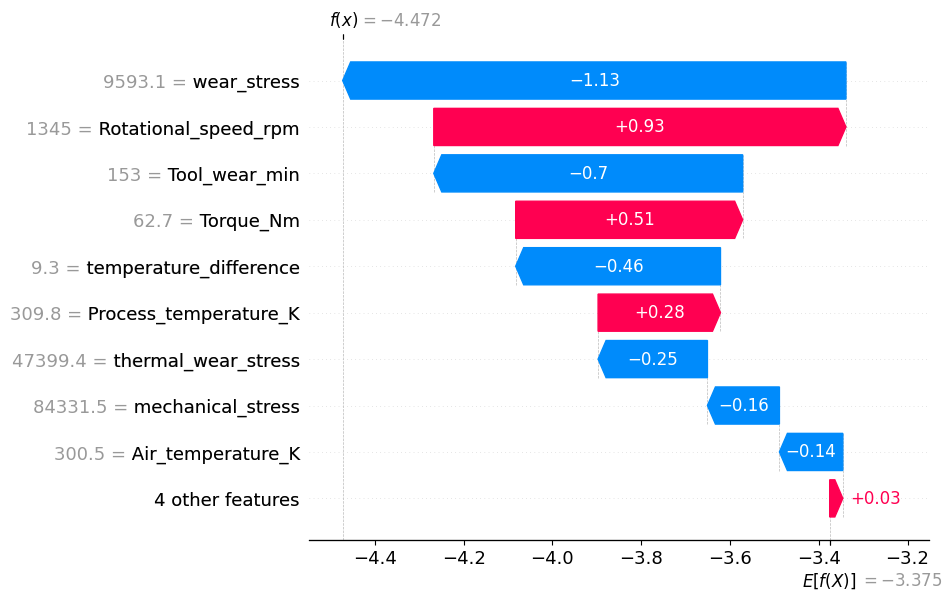

In [50]:
sample_index = 0

sample = X_test.iloc[[sample_index]]

sample_shap = explainer.shap_values(sample)

shap.waterfall_plot(
    shap.Explanation(
        values=sample_shap[0],
        base_values=explainer.expected_value,
        data=sample.iloc[0],
        feature_names=X_test.columns
    )
)

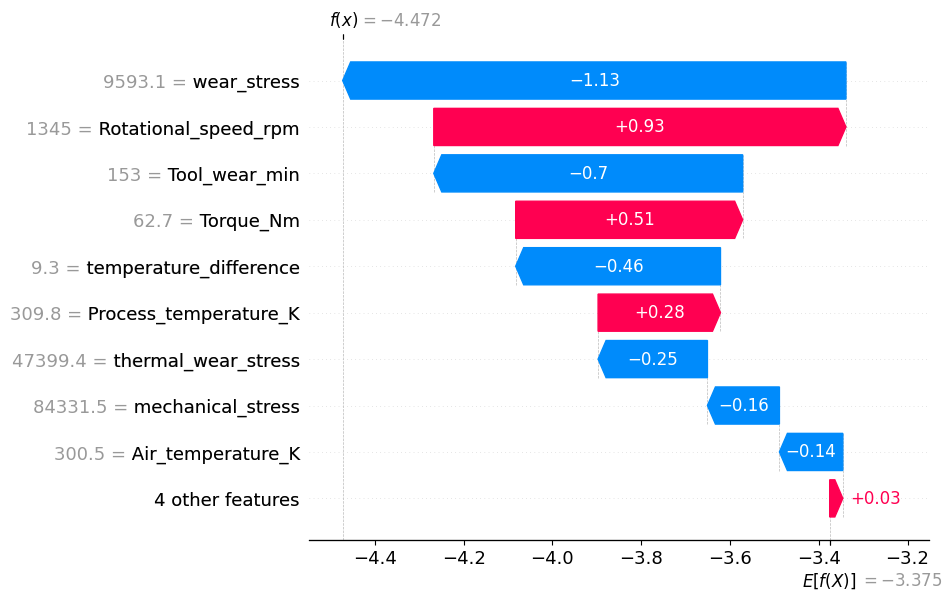

In [51]:
sample_index = 0

sample = X_test.iloc[[sample_index]]

sample_shap = explainer.shap_values(sample)

shap.waterfall_plot(
    shap.Explanation(
        values=sample_shap[0],
        base_values=explainer.expected_value,
        data=sample.iloc[0],
        feature_names=X_test.columns
    )
)

In [52]:
import numpy as np
import pandas as pd

feature_impact = pd.DataFrame({
    "feature": X_test.columns,
    "shap_value": sample_shap[0],
    "abs_shap": np.abs(sample_shap[0])
}).sort_values("abs_shap", ascending=False)

feature_impact.head(5)

,feature,shap_value,abs_shap
10,wear_stress,-1.133666,1.133666
2,Rotational_speed_rpm,0.928468,0.928468
4,Tool_wear_min,-0.695838,0.695838
3,Torque_Nm,0.511302,0.511302
8,temperature_difference,-0.461314,0.461314


In [53]:
top_features = feature_impact.head(3)["feature"].tolist()

explanation_text = (
    f"Failure risk increased mainly due to {top_features[0]}, "
    f"{top_features[1]}, and {top_features[2]}."
)

print(explanation_text)

Failure risk increased mainly due to wear_stress, Rotational_speed_rpm, and Tool_wear_min.
